# 1 · Where the matrices come from

**Math primer for the orthogonal engine mount work — notebook 1 of 7.**

Before any of the paper's cleverness, there is a boring but load-bearing step:
turning "two masses joined by springs" into $[M]\{\ddot q\} + [K]\{q\} = \{f\}$.
If the matrix assembly feels like magic, everything built on it will too.

This notebook does it entirely by hand, on a system small enough to check on
paper, and then shows the *assembly rule* that scales to the six-degree-of-freedom
engine.

**You should come out knowing:** what each entry of $[K]$ physically means, why
off-diagonal entries are called *coupling*, and how a stiffness matrix is built
by summing one contribution per spring.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eigh
import primer
from primer import SERIES, INK, INK2, GRID, tidy
primer.use_style()

## 1.1 · The system

Wall — spring $k_1$ — mass $m_1$ — spring $k_2$ — mass $m_2$.

Let $q_1, q_2$ be the displacements of the two masses from their rest positions.

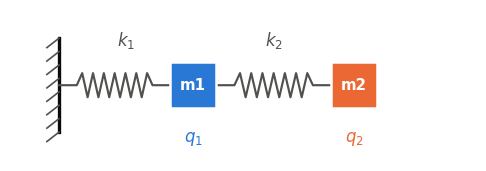

In [2]:
fig, ax = plt.subplots(figsize=(5.4, 1.5))
primer.chain_2dof(ax, u=(0, 0))
ax.text(0.5, 0.30, "$k_1$", ha="center", color=INK2, fontsize=10)
ax.text(1.6, 0.30, "$k_2$", ha="center", color=INK2, fontsize=10)
ax.text(1.0, -0.42, "$q_1$", ha="center", color=SERIES[0], fontsize=10)
ax.text(2.2, -0.42, "$q_2$", ha="center", color=SERIES[1], fontsize=10)
plt.tight_layout(); plt.show()

## 1.2 · Newton, one mass at a time

Spring $k_2$ is stretched by $q_2 - q_1$. It therefore pulls $m_1$ forward with
$k_2(q_2-q_1)$ and pulls $m_2$ backward with the same magnitude. Spring $k_1$ is
stretched by $q_1$ and pulls $m_1$ back with $k_1 q_1$.

$$m_1\ddot q_1 = -k_1 q_1 + k_2(q_2-q_1) + f_1$$
$$m_2\ddot q_2 = -k_2(q_2-q_1) + f_2$$

Move everything that is not an inertia or force term to the left:

$$m_1\ddot q_1 + (k_1+k_2)q_1 - k_2 q_2 = f_1$$
$$m_2\ddot q_2 - k_2 q_1 + k_2 q_2 = f_2$$

Which is exactly

$$\begin{bmatrix}m_1&0\\0&m_2\end{bmatrix}
\begin{Bmatrix}\ddot q_1\\ \ddot q_2\end{Bmatrix} +
\begin{bmatrix}k_1+k_2&-k_2\\-k_2&k_2\end{bmatrix}
\begin{Bmatrix}q_1\\ q_2\end{Bmatrix} =
\begin{Bmatrix}f_1\\ f_2\end{Bmatrix}$$

Nothing has happened except bookkeeping. **That is the whole content of "writing
it in matrix form".**

In [3]:
m1, m2 = 2.0, 1.0
k1, k2 = 800.0, 400.0

M = np.array([[m1, 0.0],
              [0.0, m2]])
K = np.array([[k1 + k2, -k2],
              [-k2,      k2]])
print("M =\n", M)
print("\nK =\n", K)

M =
 [[2. 0.]
 [0. 1.]]

K =
 [[1200. -400.]
 [-400.  400.]]


## 1.3 · What the entries mean

Read column $j$ of $[K]$ as: *hold every coordinate at zero except $q_j = 1$, and
report the forces you must apply at each coordinate to hold it there.*

Push $m_1$ to $q_1 = 1$ while pinning $m_2$ at zero: you must fight both springs,
so you need $k_1+k_2$ at coordinate 1 — and you must also *hold* $m_2$ back with
$-k_2$, because spring $k_2$ is now pushing it. That is column 1.

Two consequences worth internalising:

* $K_{ij}$ is the force at $i$ caused by a unit displacement at $j$. Because the
  springs are conservative, $K_{ij}=K_{ji}$ — **the stiffness matrix is
  symmetric**, always.
* $K_{12}\ne 0$ says coordinate 1 and coordinate 2 are **coupled**: you cannot
  move one without a force appearing at the other. Coupling is not a property of
  the physics alone — it is a property of the physics *and the coordinates you
  chose*. Notebook 4 leans on that hard.

In [4]:
# Column j of K, obtained the way the definition says: unit displacement, hold the rest.
for j in range(2):
    q = np.zeros(2); q[j] = 1.0
    print(f"unit displacement at coordinate {j+1}  ->  forces needed: {K @ q}")

print("\nsymmetric?", np.allclose(K, K.T))

unit displacement at coordinate 1  ->  forces needed: [1200. -400.]
unit displacement at coordinate 2  ->  forces needed: [-400.  400.]

symmetric? True


## 1.4 · The assembly rule (this is the part that scales)

Building $[K]$ by writing Newton's law for every mass works for two masses and
becomes hopeless for six degrees of freedom with four mounts. The scalable
version: **each spring contributes its own matrix, and you add them up.**

A spring of rate $k$ connecting coordinates $i$ and $j$ stores energy
$\tfrac12 k (q_j - q_i)^2$. Write $q_j - q_i = \{b\}^\mathsf{T}\{q\}$ with
$\{b\}$ a vector of $-1$ and $+1$ in the right slots. Then the energy is
$\tfrac12 k (\{b\}^\mathsf{T}\{q\})^2$ and the contribution to $[K]$ is

$$[K]_{\text{spring}} = k\,\{b\}\{b\}^\mathsf{T}$$

An outer product — a rank-1 matrix. This is the *entire* idea behind assembling
the engine's $6\times6$ stiffness matrix later: each mount contributes
$k\,\{b\}\{b\}^\mathsf{T}$ for each of its three directions, where $\{b\}$ says
how that mount's deflection depends on the six rigid-body coordinates.

In [5]:
def spring_K(k, b, n=2):
    """Stiffness contribution of one spring, k * b b^T."""
    b = np.asarray(b, dtype=float).reshape(n, 1)
    return k * (b @ b.T)

# spring 1 connects ground to coordinate 1  ->  deflection = q1        -> b = [1, 0]
# spring 2 connects coordinate 1 to 2       ->  deflection = q2 - q1   -> b = [-1, 1]
K_assembled = spring_K(k1, [1, 0]) + spring_K(k2, [-1, 1])

print("assembled:\n", K_assembled)
print("\nsame as the hand-derived K?", np.allclose(K, K_assembled))

assembled:
 [[1200. -400.]
 [-400.  400.]]

same as the hand-derived K? True


### Why the outer product is always symmetric and positive semi-definite

$\{b\}\{b\}^\mathsf{T}$ is symmetric by construction, and
$\{q\}^\mathsf{T}\{b\}\{b\}^\mathsf{T}\{q\} = (\{b\}^\mathsf{T}\{q\})^2 \ge 0$.
So a sum of springs can never produce a negative stiffness, and $[K]$ is singular
exactly when there is a rigid-body motion no spring resists. Useful sanity check
on a real model: if `eigvalsh(K)` has a near-zero entry, some direction is
unrestrained.

In [6]:
print("eigenvalues of K:", np.linalg.eigvalsh(K))

# drop the ground spring: now the pair can drift together, unrestrained
K_free = spring_K(k2, [-1, 1])
print("without the ground spring:", np.linalg.eigvalsh(K_free))
print("  -> a zero: the rigid-body drift mode", np.linalg.eigh(K_free)[1][:, 0])

eigenvalues of K: [ 234.3146 1365.6854]
without the ground spring: [  0. 800.]
  -> a zero: the rigid-body drift mode [-0.7071 -0.7071]


## 1.5 · Changing coordinates

Coordinates are a choice. Suppose instead of $(q_1, q_2)$ you use
$(q_1,\ \Delta)$ where $\Delta = q_2 - q_1$ is the spring-2 stretch. The old
coordinates in terms of the new are $\{q\} = [T]\{p\}$ with

$$[T]=\begin{bmatrix}1&0\\1&1\end{bmatrix}$$

Substituting into the equations and pre-multiplying by $[T]^\mathsf{T}$ (which
keeps the energy interpretation intact) gives

$$[T]^\mathsf{T}[M][T]\{\ddot p\} + [T]^\mathsf{T}[K][T]\{p\} = [T]^\mathsf{T}\{f\}$$

This **congruence transform**, $A \mapsto T^\mathsf{T} A T$, is the single most
important operation in the rest of the primer. Notice what happened: $[K]$ became
diagonal — the elastic coupling vanished — but $[M]$ picked up off-diagonal terms.
The coupling did not disappear; it moved from the stiffness matrix into the mass
matrix.

In [7]:
T = np.array([[1.0, 0.0],
              [1.0, 1.0]])
Mp = T.T @ M @ T
Kp = T.T @ K @ T
print("M' =\n", Mp)
print("\nK' =\n", Kp)
print("\nelastic coupling K'_12 =", Kp[0, 1], "   inertial coupling M'_12 =", Mp[0, 1])

M' =
 [[3. 1.]
 [1. 1.]]

K' =
 [[800.   0.]
 [  0. 400.]]

elastic coupling K'_12 = 0.0    inertial coupling M'_12 = 1.0


That observation is worth sitting with, because the paper's entire trick lives
here. **Coupling is not intrinsic — it is a property of your coordinate choice**,
and there are two kinds of it (through $[M]$ and through $[K]$) that can be traded
against each other. Furusawa does not remove coupling. He arranges for the two
kinds to stand in a specific ratio.

Notebook 4 makes that concrete; notebook 7 is the paper's own version of it.

---

**Next:** [2 · Eigenvalues and mode shapes](02_eigenvalues_and_modes.ipynb)